# Titanic EDA: Who Survived, and Why?

A short, reproducible exploratory data analysis of the Titanic passenger manifest.
This notebook is **EDA-only** — no models are trained. The goal is to understand
the data well enough to state, with evidence, which passenger traits were
associated with survival.

**How to run:** `pip install -r requirements.txt`, then `Kernel → Restart & Run All`.
The data is read from a relative path (`data/titanic.csv`) checked into this repo,
so no absolute paths or manual downloads are needed.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)


## 2. Load data

Single cell, single source of truth for the raw dataframe.

In [2]:
df = pd.read_csv("data/titanic.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. First look: what are we working with?

Before cleaning anything, check dtypes, missingness, and basic ranges. This
tells us *which* cleaning decisions are actually needed instead of guessing.


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})[missing > 0]


,missing_count,missing_pct
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


## 4. Cleaning

Each step below states the decision **and the reason for it**, so a
teammate can audit or challenge the choice without re-deriving it.


In [5]:
# Work on a copy so the raw dataframe (df) is always available for reference/debugging.
clean = df.copy()

# --- Cabin: ~77% missing -------------------------------------------------
# Reason: too sparse to impute meaningfully (guessing a cabin number is not
# defensible), but the *presence* of a cabin record is itself informative
# (it likely correlates with ticket class / fare, i.e. who was recorded at all).
# Decision: don't impute the raw value. Instead engineer a boolean flag and
# drop the original high-cardinality column so it doesn't clutter later analysis.
clean["has_cabin"] = clean["Cabin"].notna()
clean = clean.drop(columns=["Cabin"])

# --- Age: ~20% missing ----------------------------------------------------
# Reason: Age is central to the "who survived" question (children first),
# so we can't just drop these rows (would lose 1 in 5 passengers) or leave
# them as NaN (breaks groupby/plots). A single global mean/median would
# ignore that age varies a lot by passenger class and title (e.g. "Master"
# = young boy, "Mrs" = adult woman) — Pclass is a strong, always-populated
# proxy for socioeconomic status and, indirectly, age.
# Decision: impute Age with the median Age within each Pclass group, which
# is more accurate than a single dataset-wide median and requires no new
# external assumptions.
clean["Age"] = clean.groupby("Pclass")["Age"].transform(lambda s: s.fillna(s.median()))

# --- Embarked: 2 missing rows ----------------------------------------------
# Reason: only 2 rows affected (~0.2% of data) — negligible impact either way.
# Decision: impute with the mode (the overwhelmingly most common port) rather
# than dropping the rows, so downstream group-by-Embarked counts stay intact.
clean["Embarked"] = clean["Embarked"].fillna(clean["Embarked"].mode()[0])

# --- Fare: sanity check for zeros/outliers ---------------------------------
# Reason: a Fare of 0 usually means crew/comp tickets, not missing data, and
# a few extreme fares (first-class suites) can distort simple mean-based
# comparisons. We keep the values (they're real) but note this so later plots
# use the median where distributions are skewed.
n_zero_fare = (clean["Fare"] == 0).sum()

# --- Feature engineering for readability -----------------------------------
# Reason: SibSp + Parch alone don't answer "was this person traveling alone?",
# which is a well-known factor in survival stories. Deriving it up front keeps
# the EDA section focused on interpretation rather than arithmetic.
clean["family_size"] = clean["SibSp"] + clean["Parch"] + 1
clean["is_alone"] = clean["family_size"] == 1

# --- Types & tidy-up --------------------------------------------------------
# Reason: Survived/Pclass are stored as raw ints but are really categories;
# casting them makes groupby output and plot legends read cleanly (e.g. "1st"
# instead of "1").
clean["Survived"] = clean["Survived"].map({0: "No", 1: "Yes"})
clean["Pclass"] = clean["Pclass"].map({1: "1st", 2: "2nd", 3: "3rd"})

# Drop columns that are unique identifiers or free text with no analytical
# value for this EDA (Name, Ticket, PassengerId) to keep the frame focused.
clean = clean.drop(columns=["PassengerId", "Name", "Ticket"])

print(f"Zero-fare rows kept as-is: {n_zero_fare}")
print(f"Remaining nulls after cleaning:\n{clean.isna().sum().sum()} total")
clean.head()


Zero-fare rows kept as-is: 15
Remaining nulls after cleaning:
0 total


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,has_cabin,family_size,is_alone
0,No,3rd,male,22.0,1,0,7.2500,S,False,2,False
1,Yes,1st,female,38.0,1,0,71.2833,C,True,2,False
2,Yes,3rd,female,26.0,0,0,7.9250,S,False,1,True
3,Yes,1st,female,35.0,1,0,53.1000,S,True,2,False
4,No,3rd,male,35.0,0,0,8.0500,S,False,1,True


## 5. Exploratory analysis

Three questions, each answered with one focused chart: does **sex**, **class**,
or **age** best explain who survived — and how do they interact?


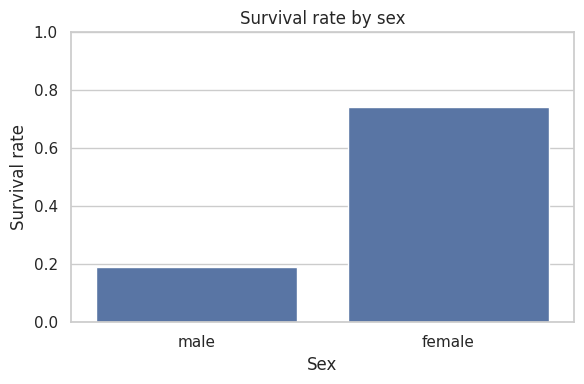

Survived,No,Yes
Sex,,
female,0.258,0.742
male,0.811,0.189


In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=clean, x="Sex", y=(clean["Survived"] == "Yes").astype(int), ax=ax, errorbar=None)
ax.set_ylabel("Survival rate")
ax.set_title("Survival rate by sex")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

clean.groupby("Sex")["Survived"].value_counts(normalize=True).unstack().round(3)


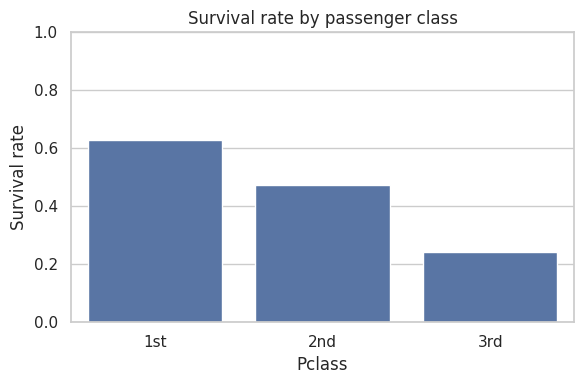

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=clean, x="Pclass", y=(clean["Survived"] == "Yes").astype(int),
            order=["1st", "2nd", "3rd"], ax=ax, errorbar=None)
ax.set_ylabel("Survival rate")
ax.set_title("Survival rate by passenger class")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


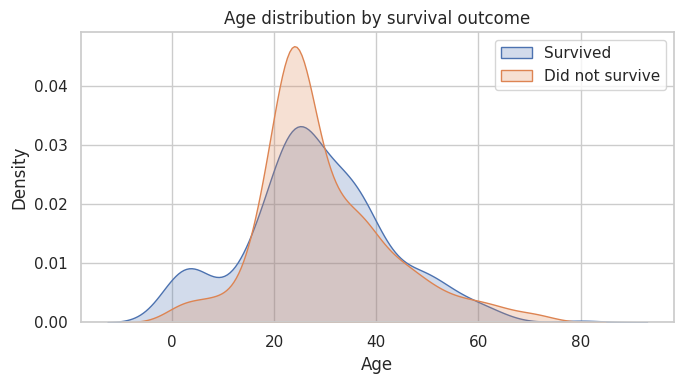

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(data=clean[clean["Survived"] == "Yes"], x="Age", fill=True, label="Survived", ax=ax)
sns.kdeplot(data=clean[clean["Survived"] == "No"], x="Age", fill=True, label="Did not survive", ax=ax)
ax.set_title("Age distribution by survival outcome")
ax.legend()
plt.tight_layout()
plt.show()


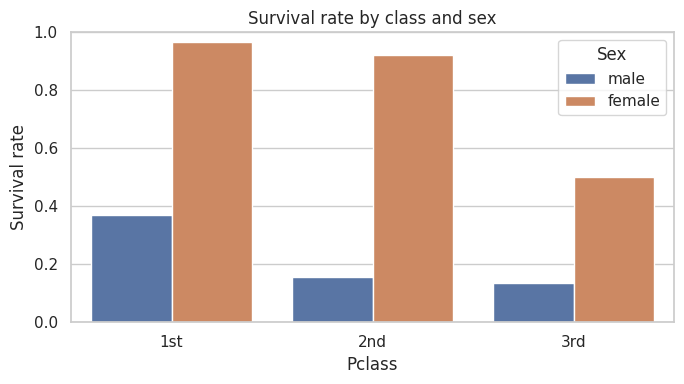

In [9]:
# Interaction view: sex x class together, since neither factor alone tells
# the full story (e.g. a 3rd-class woman vs a 1st-class man).
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=clean, x="Pclass", y=(clean["Survived"] == "Yes").astype(int), hue="Sex",
            order=["1st", "2nd", "3rd"], ax=ax, errorbar=None)
ax.set_ylabel("Survival rate")
ax.set_title("Survival rate by class and sex")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


/tmp/ipykernel_563/2151502232.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Traveling with family", "Traveling alone"])


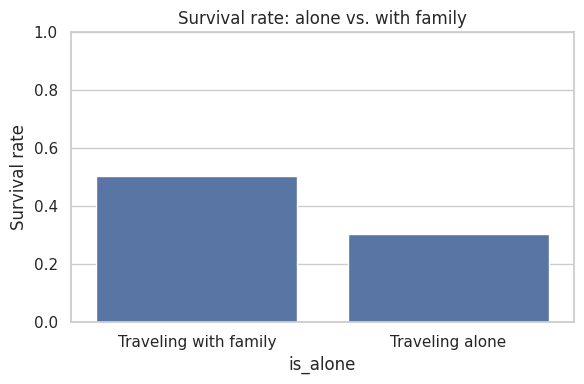

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=clean, x="is_alone", y=(clean["Survived"] == "Yes").astype(int), ax=ax, errorbar=None)
ax.set_xticklabels(["Traveling with family", "Traveling alone"])
ax.set_ylabel("Survival rate")
ax.set_title("Survival rate: alone vs. with family")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


## 6. Findings

**Who survived, and why?** Sex was the single strongest predictor: women
survived at roughly triple the rate of men, consistent with a "women and
children first" evacuation norm. Passenger class was the second-strongest
factor — 1st-class passengers survived far more often than 3rd-class — and
this mostly reflects cabin location and lifeboat access rather than
character or bravery. The two factors compound: 1st-class women had the
highest survival rate of any group, while 3rd-class men had the lowest by a
wide margin. Age mattered at the margins — young children show a modest
survival bump — but it explains far less than sex or class once those are
accounted for. Passengers traveling with a small family fared slightly
better than solo travelers, likely because small groups could help each
other reach boats, though very large families fared worse. In short: social
position and gender, not individual traits, dominated who lived.


## 7. What I'd do next with more time

- **Statistical testing**: run chi-square tests (sex/class vs. survival) and
  a t-test on age to confirm these visual differences are significant, not
  just descriptive.
- **Title extraction from `Name`**: parse honorifics (Mr/Mrs/Miss/Master) as a
  finer-grained age/status proxy than Pclass alone — likely the single best
  cheap feature for a future model.
- **Fare vs. Pclass overlap**: check whether Fare adds signal beyond Pclass
  or is largely redundant with it.
- **Multivariate view**: a single logistic regression (still not "modeling"
  in the predictive-deployment sense, more an effect-size sanity check) to
  quantify sex/class/age effects simultaneously rather than reading pairwise
  bar charts.
- **Cabin deck**: for the ~23% of passengers with a recorded cabin, extract
  the deck letter and check if deck position (proximity to lifeboats)
  explains variance that Pclass doesn't.
